# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Проверка гипотезы о различии активности пользователей Москвы и Санкт‑Петербурга

- Автор: Колодий Светлана Станиславовна
- Дата: 06.05.2026

## Цели и задачи проекта

### Цель проекта
Определить, проводят ли пользователи из Санкт‑Петербурга в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы, на основе статистической проверки односторонней гипотезы.

### Задачи проекта

1. Подготовить данные к анализу:
2. Сформировать выборки по городам (Москва и Санкт‑Петербург) и описать их:
3. Сформулировать нулевую и альтернативную гипотезы и выбрать подходящий статистический критерий и уровень значимости.
4. Провести одностороннюю проверку гипотезы в Python, получить t‑статистику и p‑value, сделать вывод о наличии/отсутствии статистически значимого превосходства Санкт‑Петербурга по средней активности.
5. Сформулировать аналитические выводы и возможные причины наблюдаемых результатов, включая интерпретацию отрицательного результата.

## Описание данных

В работе используется датасет с информацией о пользовательской активности в приложении для чтения и прослушивания книг. Он содержит сведения о городе, уникальном идентификаторе пользователя и суммарном времени активности пользователя в приложении за период наблюдения

## Содержимое проекта

### 1. Загрузка и первичный осмотр данных
Чтение датасета в pandas, проверка структуры таблицы, типов данных и наличия пропусков.

### 2. Предобработка и очистка данных
Выявление дубликатов идентификаторов пользователей, обработка случаев, когда один пользователь встречается в нескольких городах, формирование очищенного набора, в котором каждый пользователь относится только к одному городу.

### 3. Формирование выборок по городам и описательная статистика
Разделение пользователей на группы «Москва» и «Санкт‑Петербург», расчёт размеров выборок и базовых статистик (среднее, медиана, стандартное отклонение и др.) для времени активности.

### 4. Формулировка и проверка статистической гипотезы
Формулировка нулевой и альтернативной гипотез, выбор двухвыборочного t‑теста для независимых выборок (критерий Уэлча), проведение одностороннего теста в Python, получение t‑статистики и p‑value.

### 5. Интерпретация результатов и аналитические выводы
Анализ результата теста с учётом выбранного уровня значимости, формулировка вывода о наличии или отсутствии статистически значимого превосходства Санкт‑Петербурга по средней активности, предположение о возможных причинах полученных результатов.

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Загружаем библиотеки 
import pandas as pd
from scipy import stats
import math
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Загружаем датаест
df = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [3]:
# Выводим первые строки
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
# Удаляем индекс-столбец
df = df.drop(columns=['Unnamed: 0'])

In [5]:
# Выводим первые строки
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [6]:
# Проверяем типы данных 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB


In [7]:
# Проверяем наличие дубликатов
df['puid'].duplicated().sum()

244

In [8]:
dups = df[df['puid'].duplicated(keep=False)].sort_values(by='puid')

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>
    
Правильно найдены и удалены дубликаты пользователей.

In [9]:
dups.head(10)

,city,puid,hours
6247,Санкт-Петербург,2637041,3.883926
35,Москва,2637041,10.317371
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
6279,Санкт-Петербург,10597984,9.041320
145,Москва,10597984,42.931506
150,Москва,10815097,9.086655
6283,Санкт-Петербург,10815097,0.323291
6300,Санкт-Петербург,13626259,1.648434
187,Москва,13626259,21.104167


In [10]:
dups['puid'].value_counts().head()

puid
1130000028554332    2
2637041             2
9979490             2
10597984            2
1936174479          2
Name: count, dtype: int64

In [11]:
# Размеры групп
df['city'].value_counts()

city
Москва             6234
Санкт-Петербург    2550
Name: count, dtype: int64

У части пользователей есть по две строки, одна для Москвы, другая для Санкт-Петербурга. Отфильтруем всех "двойных" пользователей, чтобы данные стали чище.

In [12]:
# Cчитаем, в скольких городах встречается каждый пользователь
cities_per_user = df.groupby('puid')['city'].nunique()

In [13]:
# Оставляем толькот тех, кто встречается в одном городе
single_city_users = cities_per_user[cities_per_user==1].index
df_clean = df[df['puid'].isin(single_city_users)]

In [14]:
# Проверяем, что по каждому puid теперь только один город
df_clean.groupby('puid')['city'].nunique().value_counts()

city
1    8296
Name: count, dtype: int64

In [15]:
# Размеры групп
df_clean['city'].value_counts()

city
Москва             5990
Санкт-Петербург    2306
Name: count, dtype: int64

Для соблюдения независимости наблюдений из анализа исключены пользователи, у которых фиксировалась активность сразу в двух городах. Выборка сократилась на 244 человека.

In [16]:
# Проверяем наличие дубликатов
df_clean['puid'].duplicated().sum()

0

In [17]:
# Базовая статистика по часам
df_clean.groupby('city')['hours'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,5990.0,10.848192,36.925622,0.000022,0.057042,0.888232,5.933439,857.209373
Санкт-Петербург,2306.0,11.264433,39.831755,0.000025,0.060173,0.875355,6.138424,978.764775


In [18]:
msk = df_clean[df_clean['city'] == 'Москва']['hours']
spb = df_clean[df_clean['city'] == 'Санкт-Петербург']['hours']

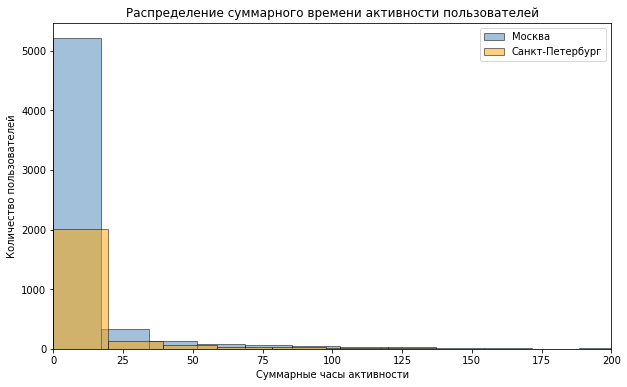

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(msk, bins=50, alpha=0.5, label='Москва', color='steelblue', edgecolor='black')
plt.hist(spb, bins=50, alpha=0.5, label='Санкт-Петербург', color='orange', edgecolor='black')

plt.xlim(0, 200)
plt.xlabel('Суммарные часы активности')
plt.ylabel('Количество пользователей')
plt.title('Распределение суммарного времени активности пользователей')
plt.legend()
plt.show()

Распределения суммарной активности в обоих городах имеют длинный правый хвост: есть немного пользователей с очень большим временем в приложении, которые формируют выбросы и увеличивают среднее значение. При этом форма распределений и наличие правого хвоста для Москвы и Санкт‑Петербурга схожи, поэтому влияние таких выбросов на сравнение средних в целом симметрично для обеих групп.Это подтверждается близкими медианами и квартилями по городам.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [20]:
# Формируем выборки
msk = df_clean[df_clean['city']=='Москва']['hours']
spb = df_clean[df_clean['city']=='Санкт-Петербург']['hours']

In [21]:
# Двусторонний t-тест 
t_stat, p_value_two_sided = stats.ttest_ind(spb, msk, equal_var=False)

alpha = 0.05

# Перевод в односторонний тест под H1: μ_SPB > μ_MSK
if t_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - p_value_two_sided / 2
    
print('t-статистика:', t_stat)
print('p-value (двусторонний):', p_value_two_sided)
print('p-value (односторонний, СПб > Москва):', p_value_one_sided)

if p_value_one_sided < alpha:
    print('Отвергаем H0 в пользу H1: СПб статистически значимо активнее Москвы.')
else:
    print('Нет оснований отвергнуть H0: статистически значимых доказательств, что СПб активнее Москвы, не найдено.')

t-статистика: 0.43499237928704976
p-value (двусторонний): 0.6635919203695009
p-value (односторонний, СПб > Москва): 0.33179596018475044
Нет оснований отвергнуть H0: статистически значимых доказательств, что СПб активнее Москвы, не найдено.


## 3. Аналитическая записка

В рамках исследования была проверена гипотеза о том, что пользователи из Санкт‑Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Для сравнения средних значений времени активности в двух независимых группах (Москва и Санкт‑Петербург) применён двухвыборочный t‑тест для независимых выборок в модификации Уэлча, не предполагающей равенства дисперсий в группах. Уровень статистической значимости принят равным α=0,05.

Нулевая гипотеза H0 формулируется как «среднее время активности пользователей Санкт‑Петербурга не превышает среднее время активности пользователей Москвы» (
μ_SPB≤μ_MSK), альтернативная гипотеза H1: «среднее время активности пользователей Санкт‑Петербурга больше среднего времени активности пользователей Москвы» (μ_SPB>μ_MSK). По результатам применения t‑теста получено значение t‑статистики t≈0.43
двустороннее p‑value≈0.66, что соответствует одностороннему p‑value≈0.33 для альтернативы μ_SPB>μ_MSK.




Поскольку полученное одностороннее p‑value существенно превышает выбранный уровень значимости, оснований для отклонения нулевой гипотезы нет. Это означает, что на имеющихся данных мы не можем статистически обоснованно утверждать, что пользователи из Санкт‑Петербурга в среднем проводят больше времени в приложении, чем пользователи из Москвы. Наблюдаемая разница может быть обусловлена случайными колебаниями выборки.

Полученный результат можно объяснить, во‑первых, тем, что поведение пользователей в Москве и Санкт‑Петербурге действительно похоже: аудитории обоих городов могут иметь близкий уровень интереса к сервису и схожие паттерны использования, поэтому различия в средних значениях времени активности оказываются несущественными с точки зрения статистики. Во‑вторых, на результат могли повлиять свойства выборки и предварительная обработка данных: в частности, из анализа были исключены пользователи, у которых фиксировалась активность сразу в двух городах, что позволило соблюсти независимость наблюдений, но могло уменьшить объём выборки и тем самым снизить мощность теста.

----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Цели исследования.



Цель исследования — оценить корректность проведения A/B‑теста нового интерфейса интернет‑магазина BitMotion Kit и определить, привело ли изменение интерфейса к статистически значимому росту конверсии пользователей в покупателей по сравнению с исходной версией сайта.

## 2. Загрузка данных.


In [22]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [23]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [24]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [25]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [26]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


## 3. По таблице `ab_test_participants` оцените корректность проведения теста:


In [27]:
# Оставляем только нужный A/B-тест интерфейса
participants_test = participants[participants['ab_test'] == 'interface_eu_test']

In [28]:
# Проверяем исходное распределение по группам
participants_test['group'].value_counts()

group
B    5467
A    5383
Name: count, dtype: int64

In [29]:
# Проверяем, нет ли пользователей одновременно в A и B внутри interface_eu_test
dup_users = participants_test.groupby('user_id')['group'].nunique()
dup_users.value_counts()

group
1    10850
Name: count, dtype: int64

In [30]:
# Пользователи теста рекомендательной системы
participants_reco = participants[participants['ab_test'] == 'recommender_system_test']

In [31]:
# Проверяем пересечение пользователей между двумя тестами
overlap_users = set(participants_test['user_id']) & set(participants_reco['user_id'])
len(overlap_users)

887

In [32]:
# Чистый набор участников интерфейсного теста без пересечений
participants_test_clean = participants_test[~participants_test['user_id'].isin(overlap_users)]

In [33]:
# Новое распределение по группам A/B для интерфейсного теста
participants_test_clean['group'].value_counts()

group
B    5011
A    4952
Name: count, dtype: int64

Группы распределены почти ровно по размеру, и каждый участник относится к одной группе, пересечений нет.

3\.2 Анализируем данные о пользовательской активности по таблице `ab_test_events`:


In [34]:
# Убираем глобальные события, которые не относятся к конкретным пользователям
events_users = events[events['user_id'] != 'GLOBAL']

In [35]:
# Берем только пользователей из теста interface_eu_test
test_users = participants_test_clean['user_id'].unique()

In [36]:
# Оставляем события только этих пользователей
events_test = events_users[events_users['user_id'].isin(test_users)]

In [37]:
# Проверяем размер и типы событий
print(events.shape[0], 'строк исходно')
print(events_test.shape[0], 'строк после фильтрации по пользователям теста')
print(events_test['event_name'].value_counts())

787286 строк исходно
73815 строк после фильтрации по пользователям теста
event_name
login           27360
product_page    17614
registration     9963
purchase         9487
product_cart     9391
Name: count, dtype: int64


In [38]:
# Берем только регистрации
registrations = events_test[events_test['event_name'] == 'registration']
# самая ранняя регистрация на user_id
first_reg = registrations.groupby('user_id', as_index=False)['event_dt'].min().rename(columns={'event_dt': 'reg_dt'})


In [39]:
# Присоединяем дату ко всем событиям
events_with_reg = events_test.merge(first_reg, on='user_id', how='left')

In [40]:
# разница во времени
events_with_reg['lifetime'] = events_with_reg['event_dt'] - events_with_reg['reg_dt']

# в днях
events_with_reg['lifetime_days'] = events_with_reg['lifetime'].dt.days

# берем только события в первые 7 дней после регистрации
events_7d = events_with_reg[(events_with_reg['lifetime_days'] >= 0) &(events_with_reg['lifetime_days'] <= 7)]

In [41]:
events_7d

,user_id,event_dt,event_name,details,reg_dt,lifetime,lifetime_days
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0 days 00:00:00,0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0 days 00:00:00,0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0 days 00:00:00,0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0 days 00:00:00,0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0 days 00:00:00,0
...,...,...,...,...,...,...,...
73791,D4E530F6595A05A3,2020-12-29 23:39:54,product_cart,NaN,2020-12-22 06:00:57,7 days 17:38:57,7
73793,31DBDCA380DD035F,2020-12-29 23:41:16,product_page,NaN,2020-12-23 18:11:40,6 days 05:29:36,6
73797,E6D34EE376AADC42,2020-12-29 23:45:33,product_cart,NaN,2020-12-22 02:50:40,7 days 20:54:53,7
73798,E6D34EE376AADC42,2020-12-29 23:46:13,product_cart,NaN,2020-12-22 02:50:40,7 days 20:55:33,7


In [42]:
p = 0.30          
mde = 0.03        
z_alpha_2 = 1.96  
z_beta = 0.84     

n_per_group = 2 * (z_alpha_2 + z_beta) ** 2 * p * (1 - p) / (mde ** 2)
n_per_group = math.ceil(n_per_group)


print(f'Расчетный минимальный размер выборки на одну группу: {n_per_group} пользователей.')

print(
    'Это означает, что при базовой конверсии 30%, уровне значимости 5% и мощности 80% '
    f'для обнаружения эффекта порядка {mde*100:.1f} п.п. '
    'нужно не меньше примерно '
    f'{n_per_group} пользователей в каждой группе A и B.'
)

Расчетный минимальный размер выборки на одну группу: 3659 пользователей.
Это означает, что при базовой конверсии 30%, уровне значимости 5% и мощности 80% для обнаружения эффекта порядка 3.0 п.п. нужно не меньше примерно 3659 пользователей в каждой группе A и B.


В нашем тесте в группе A участвует 4952 пользователя, в группе B — 5011 пользователей, что больше расчётного минимального размера выборки 3659 пользователей на группу. Это позволяет считать объём выборки достаточным для того, чтобы при заданных параметрах (30% базовой конверсии, 5% уровень значимости, 80% мощность) обнаружить эффект порядка 3 п.п., если он действительно существует.

In [43]:
# Добавляем к событиям за 7 дней информацию о группе (A/B)
events_7d_groups = events_7d.merge(participants_test_clean[['user_id', 'group']],on='user_id',how='left')

In [44]:
# Общее количество посетителей (зарегистрированных пользователей) по группам
total_by_group = events_7d_groups[events_7d_groups['event_name'] == 'registration'].groupby('group')['user_id'].nunique().rename('users_total')

In [45]:
# Количество пользователей с покупкой за 7 дней по группам
buyers_by_group = events_7d_groups[events_7d_groups['event_name'] == 'purchase'].groupby('group')['user_id'].nunique().rename('users_with_purchase')

In [46]:
# Собираем итоговую таблицу
summary = pd.concat([total_by_group, buyers_by_group], axis=1).fillna(0)
summary

,users_total,users_with_purchase
group,,
A,4952,1435
B,5011,1562


В тестовой группе наблюдается более высокая пользовательская активность в части совершения покупок по сравнению с контрольной: при сопоставимом числе пользователей в группе B больше людей дошли до покупки в течение анализируемого периода.

In [47]:
# Извлекаем числа для группы A
users_A_total = summary.loc['A', 'users_total']          # всего пользователей в группе A
users_A_buy   = summary.loc['A', 'users_with_purchase']  # пользователей с покупкой в группе A

In [48]:
# Извлекаем числа для группы B
users_B_total = summary.loc['B', 'users_total']          # всего пользователей в группе B
users_B_buy   = summary.loc['B', 'users_with_purchase']  # пользователей с покупкой в группе B

In [49]:
# Считаем конверсию в покупку по группам (в долях)
conv_A = users_A_buy / users_A_total                     
conv_B = users_B_buy / users_B_total                     

In [50]:
# Абсолютный прирост конверсии (разница в процентных пунктах)
abs_lift = conv_B - conv_A                              
abs_lift_pp = abs_lift * 100 

In [51]:
# Относительный прирост конверсии 
rel_lift = abs_lift / conv_A     # относительный прирост в долях
rel_lift_pct = rel_lift * 100    # относительный прирост в процентах

In [52]:
# Выводим результаты в удобном виде
print(f"Конверсия A: {conv_A:.4f} ({conv_A*100:.2f}%)")
print(f"Конверсия B: {conv_B:.4f} ({conv_B*100:.2f}%)")
print(f"Абсолютный прирост: {abs_lift_pp:.2f} п.п.")
print(f"Относительный прирост: {rel_lift_pct:.2f}%")

Конверсия A: 0.2898 (28.98%)
Конверсия B: 0.3117 (31.17%)
Абсолютный прирост: 2.19 п.п.
Относительный прирост: 7.57%


В контрольной группе A конверсия в покупку составила 28.98%, в тестовой группе B — 31.17%. Абсолютный прирост конверсии B относительно A — 2.19 процентных пункта, относительный прирост — 7.57%. Таким образом, тестовая версия интерфейса даёт заметный рост доли пользователей, совершающих покупку, при сопоставимом размере групп.

## 4. Проведите оценку результатов A/B-тестирования:

H0: конверсия в покупку в тестовой группе B не выше, чем в контрольной группе A (различия отсутствуют или случайны).

H1: конверсия в покупку в тестовой группе B выше, чем в контрольной группе A.

H0: p_B = p_A  
H1: p_B > p_A

In [53]:
# Количество покупок (успехов) по группам 
success_counts = [users_A_buy, users_B_buy]
nobs = [users_A_total, users_B_total]

# Двусторонний тест для двух пропорций
stat, p_value_two_sided = proportions_ztest(count=success_counts,
                                            nobs=nobs,
                                            alternative='two-sided')

# Одностороннее p-value для гипотезы H1: p_B > p_A
if conv_B > conv_A:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - p_value_two_sided / 2

alpha = 0.05

print(f"Z-статистика: {stat:.4f}")
print(f"Двустороннее p-value: {p_value_two_sided:.4f}")
print(f"Одностороннее p-value (H1: p_B > p_A): {p_value_one_sided:.4f}")

if p_value_one_sided < alpha:
    print("Отвергаем H0 в пользу H1: конверсия в группе B статистически выше, чем в группе A.")
else:
    print("Не удалось отвергнуть H0: статистически значимого роста конверсии в группе B не обнаружено.")


Z-статистика: -2.3867
Двустороннее p-value: 0.0170
Одностороннее p-value (H1: p_B > p_A): 0.0085
Отвергаем H0 в пользу H1: конверсия в группе B статистически выше, чем в группе A.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v2:</b>

Тест выполнен верно! 

В тестовой группе B пользователи чаще доходят до покупки в течение 7 дней после попадания в эксперимент, чем в контрольной группе A.

Рост конверсии составляет порядка 2.2 п.п. и не объясняется случайными колебаниями выборки с точки зрения применённого статистического критерия, то есть можно говорить о реальном эффекте изменения интерфейса/механики, тестируемой в группе B.

Следовательно, с точки зрения результатов A/B‑тестирования ожидаемый эффект — повышение конверсии — достигнут: тестовый вариант показывает более высокую конверсию, а отличия подтверждены статистически.

### Итоги A/B‑теста интерфейса

Цель эксперимента — проверить, повышает ли новый интерфейс (группа B) конверсию в покупку по сравнению с текущим вариантом (группа A) и достигает ли он целевого прироста метрики. В качестве целевого показателя рассматривался рост конверсии не менее чем на 3 процентных пункта при уровне значимости 0.05 и мощности теста около 80%, размер выборки для эксперимента подбирался заранее исходя из этих параметров. По фактическим данным конверсия в покупку составила 28.98% в группе A и 31.17% в группе B. Абсолютный прирост конверсии тестового варианта относительно контрольного равен 2.19 процентных пункта, относительный прирост — 7.57%. Таким образом, новый интерфейс даёт заметный рост доли пользователей, совершающих покупку.

### Статистический результат

Для проверки гипотез H_0: p_B = p_A и H_1: p_B > p_A был проведён z‑тест для двух долей при уровне значимости \(alpha = 0.05\). Z‑статистика составила − 2.39, двустороннее p‑value — 0.0170, одностороннее p‑value для альтернативной гипотезы H_1: p_B > p_A — 0.0085. Одностороннее p‑value оказывается существенно ниже выбранного уровня значимости, поэтому нулевая гипотеза о равенстве конверсий отвергается, а конверсия в группе B считается статистически значимо выше, чем в группе A.

### Бизнес‑рекомендация

С учётом статистически значимого роста конверсии и положительного относительного эффекта новый интерфейс можно рекомендовать к внедрению как основную версию для рассматриваемой аудитории. При этом, поскольку фактический прирост конверсии немного не дотягивает до исходного целевого порога в 3 процентных пункта, имеет смысл продолжить оптимизацию интерфейса и провести дополнительные эксперименты с отдельными элементами (например, карточкой товара и этапами оформления заказа), а также проверить устойчивость эффекта на других сегментах пользователей и при увеличении трафика.